# 🤖 Analisis Sentimen: AI Menggantikan Manusia

**Sumber data:** Komentar TikTok (Neysa 1 + Neysa 2 + Rizky)

**Pipeline:**
1. Merge & Preprocessing teks
2. Language detection + Auto-labeling via Transformer
3. Training SVM & Evaluasi
4. Visualisasi hasil

---

## ⚙️ Install Dependencies
*(Jalankan sekali, skip jika sudah terinstall)*

In [ ]:
# !pip install pandas langdetect transformers torch scikit-learn matplotlib seaborn wordcloud sentencepiece protobuf

---
## 📥 Step 1 — Merge Data & Preprocessing Teks

In [2]:
import re
import os
import pandas as pd

os.makedirs("output", exist_ok=True)

In [3]:
# --- Load 3 sumber data ---
neysa1 = pd.read_csv("Neysa_Scrap 1_clean.csv", encoding="utf-8-sig")
neysa2 = pd.read_csv("Neysa_Scrap 2_clean.csv", encoding="utf-8-sig")
rizky  = pd.read_csv("Rizky_Hasil scrap komentar.csv", encoding="utf-8-sig")

print(f"Neysa 1 : {len(neysa1):>5} baris")
print(f"Neysa 2 : {len(neysa2):>5} baris")
print(f"Rizky   : {len(rizky):>5} baris")

# --- Merge ---
df = pd.concat([neysa1, neysa2, rizky], ignore_index=True)
df.columns = ["text"]
df.drop_duplicates(subset="text", inplace=True)
df.dropna(subset="text", inplace=True)
df.reset_index(drop=True, inplace=True)

df.to_csv("output/data_merged.csv", index=False, encoding="utf-8")
print(f"\nSetelah merge + dedup: {len(df)} baris")

Neysa 1 :   557 baris
Neysa 2 :   833 baris
Rizky   :  1569 baris

Setelah merge + dedup: 1444 baris


In [4]:
# --- Fungsi Preprocessing ---
def preprocess(text: str) -> str:
    text = str(text)
    text = re.sub(r"http\S+|www\.\S+", "", text)         # hapus URL
    text = re.sub(r"@\w+", "", text)                      # hapus @mention
    text = re.sub(r"#\w+", "", text)                      # hapus #hashtag
    text = re.sub(r"\[Sticker\]", "", text, flags=re.I)   # hapus [Sticker]
    text = re.sub(r"[^\w\s.,!?'\"()-]", " ", text)        # hapus emoji & karakter aneh
    text = re.sub(r"\s+", " ", text).strip()              # normalisasi spasi
    return text

df["text_clean"] = df["text"].apply(preprocess)
df = df[df["text_clean"].str.len() > 2].reset_index(drop=True)

df.to_csv("output/data_preprocessed.csv", index=False, encoding="utf-8")
print(f"Setelah preprocessing: {len(df)} baris")
df[["text", "text_clean"]].head(5)

Setelah preprocessing: 1387 baris


,text,text_clean
0,Do companies not realise. If A.i is trained to...,Do companies not realise. If A.i is trained to...
1,[Sticker] So why am I going to school 😭,So why am I going to school
2,my aunt who never talks about this stuff rando...,my aunt who never talks about this stuff rando...
3,Is this guy teaching robots to sew or getting ...,Is this guy teaching robots to sew or getting ...
4,why? ai could just use social media..lots of p...,why? ai could just use social media..lots of p...


---
## 🌐 Step 2 — Language Detection + Auto-Labeling

Setiap komentar dideteksi bahasanya, lalu di-route ke model transformer yang sesuai:

| Bahasa | Model |
|--------|-------|
| English (`en`) | `cardiffnlp/twitter-xlm-roberta-base-sentiment` |
| Indonesian (`id`) | `mdhugol/indonesia-bert-sentiment-classification` |
| Lainnya | `cardiffnlp/twitter-xlm-roberta-base-sentiment-multilingual` |

In [5]:
from langdetect import detect, LangDetectException
from transformers import pipeline
import torch

df = pd.read_csv("output/data_preprocessed.csv", encoding="utf-8")
print(f"Loaded {len(df)} baris")

c:\Users\Acer\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 1387 baris


In [5]:
# --- Language Detection ---
def detect_lang(text: str) -> str:
    try:
        return detect(str(text))
    except LangDetectException:
        return "en"

print("Mendeteksi bahasa...")
df["language"] = df["text_clean"].apply(detect_lang)

lang_counts = df["language"].value_counts()
print(f"Distribusi bahasa (top 10):\n{lang_counts.head(10)}")

Mendeteksi bahasa...
Distribusi bahasa (top 10):
language
en    912
id    240
tl     48
so     28
sw     23
de     15
it     10
no      9
af      9
da      9
Name: count, dtype: int64


In [6]:
# --- Load Model Transformer ---
device = 0 if torch.cuda.is_available() else -1
print(f"Device: {'GPU' if device == 0 else 'CPU'}")

print("\nLoading model English...")
pipe_en = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-xlm-roberta-base-sentiment",
    tokenizer=("cardiffnlp/twitter-xlm-roberta-base-sentiment", {"use_fast": False}),
    device=device, truncation=True, max_length=128,
)

print("Loading model Indonesian...")
pipe_id = pipeline(
    "sentiment-analysis",
    model="mdhugol/indonesia-bert-sentiment-classification",
    tokenizer=("mdhugol/indonesia-bert-sentiment-classification", {"use_fast": False}),
    device=device, truncation=True, max_length=128,
)

print("Loading model Multilingual (fallback)...")
pipe_multi = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-xlm-roberta-base-sentiment-multilingual",
    tokenizer=("cardiffnlp/twitter-xlm-roberta-base-sentiment-multilingual", {"use_fast": False}),
    device=device, truncation=True, max_length=128,
)

print("\nSemua model berhasil dimuat.")

Device: CPU

Loading model English...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 17368.26it/s]
XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading model Indonesian...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 16973.47it/s]
BertForSequenceClassification LOAD REPORT from: mdhugol/indonesia-bert-sentiment-classification
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading model Multilingual (fallback)...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 15361.79it/s]
XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base-sentiment-multilingual
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Semua model berhasil dimuat.


In [7]:
# --- Normalisasi Label ---
def normalize_label(raw_label: str) -> str:
    raw = raw_label.lower().strip()
    if raw in ("positive", "pos", "label_2", "positif"):
        return "Positif"
    if raw in ("negative", "neg", "label_0", "negatif"):
        return "Negatif"
    return "Netral"

# --- Routing & Inference ---
def get_sentiment(row):
    lang = row["language"]
    text = str(row["text_clean"])[:512]
    try:
        if lang == "id":
            result = pipe_id(text)[0]
        elif lang == "en":
            result = pipe_en(text)[0]
        else:
            result = pipe_multi(text)[0]
        return normalize_label(result["label"]), round(result["score"], 4)
    except Exception:
        return "Netral", 0.0

print("Menjalankan auto-labeling (beberapa menit)...")
results = df.apply(get_sentiment, axis=1)
df["label"]      = [r[0] for r in results]
df["confidence"] = [r[1] for r in results]

df.to_csv("output/data_labeled.csv", index=False, encoding="utf-8")
print(f"\nSelesai! Distribusi label:")
print(df["label"].value_counts())
df[["text_clean", "language", "label", "confidence"]].head(10)

Menjalankan auto-labeling (beberapa menit)...

Selesai! Distribusi label:
label
Netral     618
Negatif    522
Positif    247
Name: count, dtype: int64


,text_clean,language,label,confidence
0,Do companies not realise. If A.i is trained to...,en,Negatif,0.7817
1,So why am I going to school,en,Negatif,0.7620
2,my aunt who never talks about this stuff rando...,en,Negatif,0.8911
3,Is this guy teaching robots to sew or getting ...,en,Netral,0.7984
4,why? ai could just use social media..lots of p...,en,Negatif,0.6031
5,Wait until you find out you have been training...,en,Netral,0.6585
6,Let s all put our money together build sum lik...,en,Netral,0.4767
7,and a lot more quality control productivity lo...,en,Positif,0.5160
8,the corporate greed,en,Negatif,0.9213
9,Then the AI will be revolting. Thanks to the t...,en,Negatif,0.4588


---
## 🤖 Step 3 — Training SVM & Evaluasi

Label dari transformer dipakai sebagai **ground truth**.

Evaluasi dilakukan dengan dua cara:
1. **5-Fold Stratified Cross Validation** → estimasi akurasi yang lebih robust
2. **80/20 split final** → untuk confusion matrix dan classification report

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

os.makedirs("output/figures", exist_ok=True)

df = pd.read_csv("output/data_labeled.csv", encoding="utf-8")
df = df.dropna(subset=["text_clean", "label"])
print(f"Data: {len(df)} baris")
print(df["label"].value_counts())

In [ ]:
X = df["text_clean"].astype(str)
y = df["label"]

# --- Stopwords EN + ID ---
STOPWORDS_EN = {
    "i","me","my","we","our","you","your","he","his","she","her","it","its",
    "they","their","what","which","who","this","that","these","those",
    "am","is","are","was","were","be","been","being","have","has","had",
    "do","does","did","will","would","shall","should","may","might","can","could",
    "not","no","nor","but","and","or","so","yet","both","either","neither",
    "if","then","because","as","until","while","of","at","by","for","with",
    "about","against","between","into","through","during","before","after",
    "above","below","to","from","up","down","in","out","on","off","over",
    "under","again","further","then","once","a","an","the","just","also",
    "more","most","other","some","such","than","too","very","s","t",
}
STOPWORDS_ID = {
    "yang","dan","di","ke","dari","ini","itu","dengan","untuk","pada",
    "adalah","juga","akan","ada","tidak","sudah","saya","aku","kamu","dia",
    "mereka","kita","kami","nya","pun","bisa","buat","karena","jadi",
    "kalau","tapi","atau","lebih","agar","apa","siapa","mana","bagaimana",
    "kapan","dimana","kenapa","sangat","sekali","belum","masih",
    "lagi","saja","hanya","setelah","sebelum","seperti","semua","banyak",
    "punya","mau","maka","namun","oleh","hal","cara","tahun","orang","dapat",
}
ALL_STOPWORDS = list(STOPWORDS_EN | STOPWORDS_ID)

# --- Pipeline TF-IDF + LinearSVC ---
svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        sublinear_tf=True,
        stop_words=ALL_STOPWORDS,
    )),
    ("svm", LinearSVC(max_iter=2000)),
])

# --- 5-Fold Stratified Cross Validation ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(svm_pipeline, X, y, cv=skf, scoring="accuracy")

print("=== 5-Fold Stratified Cross Validation ===")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}  ({score*100:.1f}%)")
print(f"  -----------------------------")
print(f"  Mean : {cv_scores.mean():.4f}  ({cv_scores.mean()*100:.1f}%)")
print(f"  Std  : {cv_scores.std():.4f}")

In [ ]:
# --- Final model 80/20 untuk classification report & confusion matrix ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

svm_pipeline.fit(X_train, y_train)
y_pred = svm_pipeline.predict(X_test)

svm_acc = accuracy_score(y_test, y_pred)
print(f"=== Final Model (80/20 split) ===")
print(f"Accuracy: {svm_acc:.4f}  ({svm_acc*100:.1f}%)\n")
print(classification_report(y_test, y_pred))

In [ ]:
# --- Confusion Matrix ---
labels = ["Positif", "Negatif", "Netral"]
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_title(
    f"Confusion Matrix — SVM\n"
    f"80/20 Acc: {svm_acc*100:.1f}%  |  CV Mean: {cv_scores.mean()*100:.1f}% ± {cv_scores.std()*100:.1f}%",
    fontsize=12
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual (Transformer Label)")
plt.tight_layout()
plt.savefig("output/figures/confusion_matrix_svm.png", dpi=150)
plt.show()

In [ ]:
# --- Bar Chart: per-fold CV + SVM vs Transformer ---
avg_transformer_conf = df["confidence"].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Kiri: per-fold accuracy
fold_labels = [f"Fold {i}" for i in range(1, 6)] + ["Mean"]
fold_scores = list(cv_scores) + [cv_scores.mean()]
fold_colors = ["#7EB6D9"] * 5 + ["#4C72B0"]
bars = axes[0].bar(fold_labels, fold_scores, color=fold_colors, edgecolor="white")
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("5-Fold Cross Validation — SVM")
axes[0].axhline(cv_scores.mean(), color="#4C72B0", linewidth=1.5,
                linestyle="--", label=f"Mean = {cv_scores.mean():.3f}")
axes[0].legend(fontsize=10)
for bar, score in zip(bars, fold_scores):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.012, f"{score:.3f}",
                 ha="center", fontsize=10)

# Kanan: SVM CV mean vs Transformer avg confidence
model_names = ["SVM\n(CV Mean ± Std)", "Transformer\n(avg confidence)"]
scores_comp = [cv_scores.mean(), avg_transformer_conf]
colors_comp = ["#4C72B0", "#DD8452"]
bars2 = axes[1].bar(model_names, scores_comp, color=colors_comp, width=0.4, edgecolor="white")
axes[1].errorbar(0, cv_scores.mean(), yerr=cv_scores.std(),
                 fmt="none", color="black", capsize=6, linewidth=2)
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel("Score")
axes[1].set_title("SVM CV Mean vs Transformer Avg Confidence")
for bar, score in zip(bars2, scores_comp):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.015, f"{score:.3f}",
                 ha="center", fontsize=11)

plt.tight_layout()
plt.savefig("output/figures/model_comparison.png", dpi=150)
plt.show()

# Simpan report
with open("output/svm_report.txt", "w", encoding="utf-8") as f:
    f.write("=== 5-Fold Stratified Cross Validation ===\n")
    for i, score in enumerate(cv_scores, 1):
        f.write(f"  Fold {i}: {score:.4f}\n")
    f.write(f"  Mean : {cv_scores.mean():.4f}\n")
    f.write(f"  Std  : {cv_scores.std():.4f}\n\n")
    f.write("=== Final Model (80/20 split) ===\n")
    f.write(f"Accuracy: {svm_acc:.4f}\n\n")
    f.write(classification_report(y_test, y_pred))
    f.write(f"\nTransformer avg confidence: {avg_transformer_conf:.4f}\n")
print("Report tersimpan di output/svm_report.txt")

---
## 📊 Step 4 — Visualisasi Hasil

In [14]:
from wordcloud import WordCloud

df = pd.read_csv("output/data_labeled.csv", encoding="utf-8")
df = df.dropna(subset=["text_clean", "label"])

COLORS = {"Positif": "#2ecc71", "Negatif": "#e74c3c", "Netral": "#3498db"}
label_counts = df["label"].value_counts()
print(f"Total data: {len(df)} komentar")
print(label_counts)

Total data: 1387 komentar
label
Netral     618
Negatif    522
Positif    247
Name: count, dtype: int64


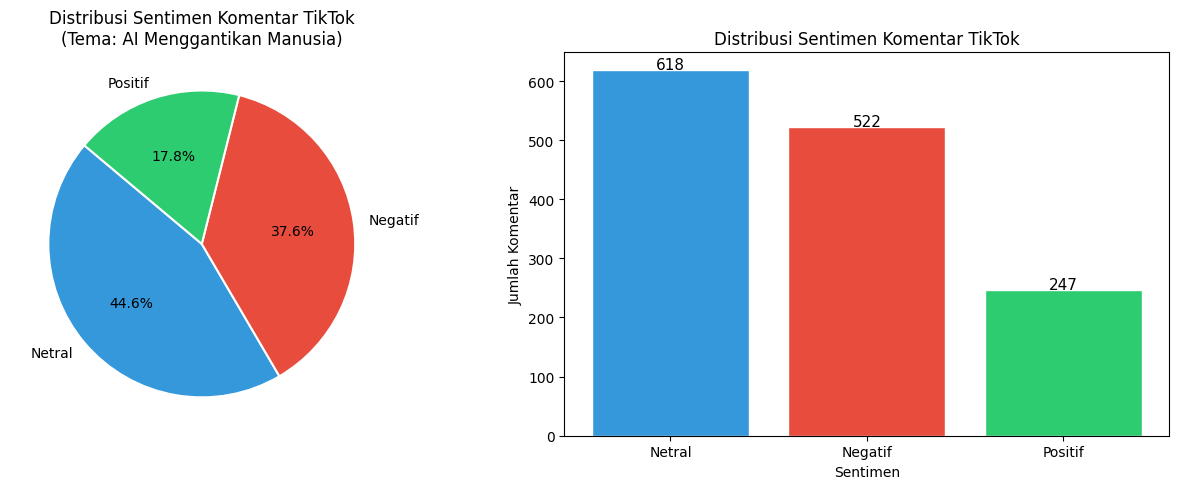

In [15]:
# --- Pie Chart & Bar Chart ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Pie
ax1.pie(
    label_counts,
    labels=label_counts.index,
    autopct="%1.1f%%",
    colors=[COLORS.get(l, "#aaa") for l in label_counts.index],
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
ax1.set_title("Distribusi Sentimen Komentar TikTok\n(Tema: AI Menggantikan Manusia)", fontsize=12)

# Bar
bars = ax2.bar(label_counts.index, label_counts.values,
               color=[COLORS.get(l, "#aaa") for l in label_counts.index],
               edgecolor="white")
for bar, val in zip(bars, label_counts.values):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
             str(val), ha="center", fontsize=11)
ax2.set_xlabel("Sentimen")
ax2.set_ylabel("Jumlah Komentar")
ax2.set_title("Distribusi Sentimen Komentar TikTok", fontsize=12)

plt.tight_layout()
plt.savefig("output/figures/sentiment_distribution_combined.png", dpi=150)
plt.show()

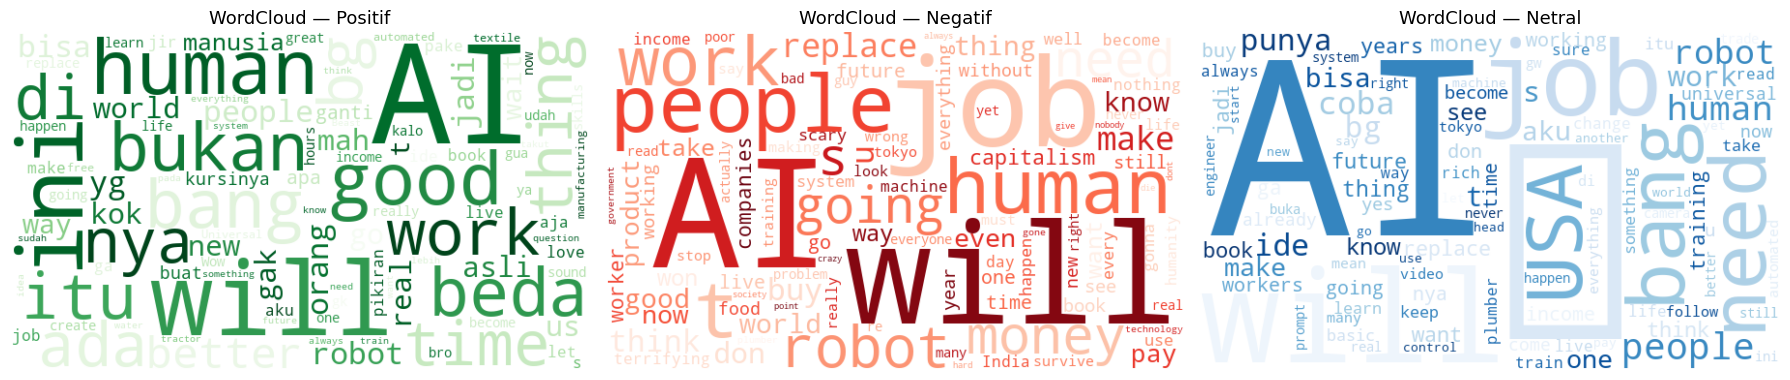

In [16]:
# --- WordCloud per Sentimen ---
cmap_map = {"Positif": "Greens", "Negatif": "Reds", "Netral": "Blues"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, label in zip(axes, ["Positif", "Negatif", "Netral"]):
    subset = df[df["label"] == label]["text_clean"].dropna()
    if subset.empty:
        ax.axis("off")
        continue
    combined = " ".join(subset.tolist())
    wc = WordCloud(
        width=600, height=350,
        background_color="white",
        colormap=cmap_map[label],
        max_words=100,
        collocations=False,
    ).generate(combined)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"WordCloud — {label}", fontsize=13)

plt.tight_layout()
plt.savefig("output/figures/wordcloud_all.png", dpi=150)
plt.show()

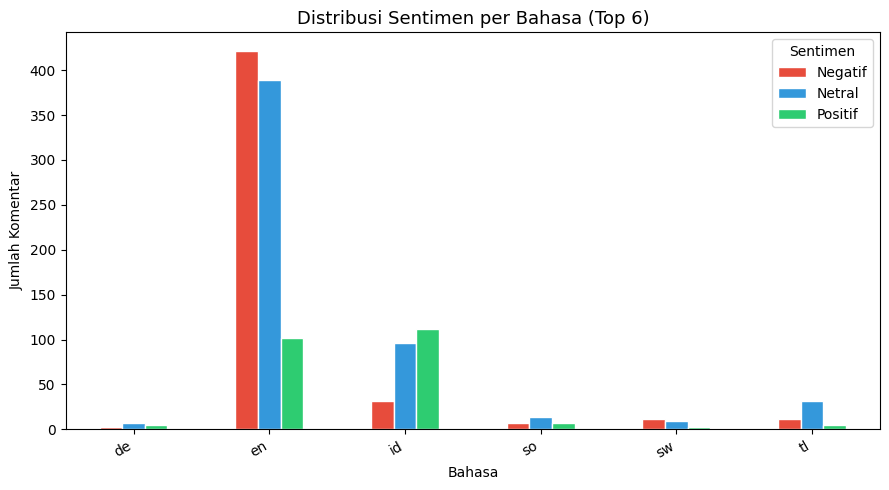


✅ Semua visualisasi selesai. File tersimpan di output/figures/


In [17]:
# --- Distribusi Sentimen per Bahasa (Top 6) ---
top_langs = df["language"].value_counts().head(6).index
lang_label = df.groupby(["language", "label"]).size().unstack(fill_value=0)
lang_label = lang_label.loc[lang_label.index.isin(top_langs)]

fig, ax = plt.subplots(figsize=(9, 5))
lang_label.plot(kind="bar", ax=ax,
                color=[COLORS.get(c, "#aaa") for c in lang_label.columns],
                edgecolor="white")
ax.set_xlabel("Bahasa")
ax.set_ylabel("Jumlah Komentar")
ax.set_title("Distribusi Sentimen per Bahasa (Top 6)", fontsize=13)
ax.legend(title="Sentimen")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("output/figures/sentiment_per_language.png", dpi=150)
plt.show()

print("\n✅ Semua visualisasi selesai. File tersimpan di output/figures/")